# 02 - ChestMNIST - Auto Encoder

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import medmnist
from pathlib import Path

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

import mlflow
import mlflow.pytorch

from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

/home/anto/miniconda3/envs/torch/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/home/anto/miniconda3/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# reproductibilité

torch.manual_seed(17)

generator = torch.Generator()
generator.manual_seed(17)

### Hyperparamètres et chargement des données

In [3]:
mlflow.set_experiment("ChestMNIST_AutoEncoder")

IMG_SIZE = 64
BATCH_SIZE = 64
LR = 1e-3
NUM_EPOCHS = 7

In [4]:
# moyenne et écart-type pour la normalisation des données
train_dataset = medmnist.ChestMNIST(
    split="train",
    download=True,
    size=IMG_SIZE,
    transform=transforms.ToTensor(),
)

imgs = torch.stack([x for x, _ in train_dataset])

imgs.shape

mean = imgs.mean()
std = imgs.std()

mean, std

(tensor(0.4979), tensor(0.2450))

In [5]:
# on applique les transformations : tenseur + normalisation
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std), # normalisation
    ] 
)

# Rechargement avec transforms
train_dataset_t = medmnist.ChestMNIST(
    split="train", download=True, size=IMG_SIZE, transform=transform
)
test_dataset_t = medmnist.ChestMNIST(
    split="test", download=True, size=IMG_SIZE, transform=transform
)
val_dataset_t = medmnist.ChestMNIST(
    split="val", download=True, size=IMG_SIZE, transform=transform
)

In [6]:
run_params = {
    "batch_size": BATCH_SIZE,
    "lr": LR,
    "num_epochs": NUM_EPOCHS,
    "optimizer": "Adam",
    "loss": "BCEWithLogitsLoss",
    "img_size": IMG_SIZE,
}

### Jeux de données et DataLoaders

Pour l'entraînement de l'autoencodeur, nous n'allons utiliser que des images de radio saines afin que le modèle puisse apprendre à reconstruire des images normales, et donc détecter les anomalies.

In [7]:
train_labels = torch.tensor(train_dataset_t.labels)
test_labels = torch.tensor(test_dataset_t.labels)
val_labels = torch.tensor(val_dataset_t.labels)

print(f"train = {train_labels.shape}, test = {test_labels.shape}, val = {val_labels.shape}")

train = torch.Size([78468, 14]), test = torch.Size([22433, 14]), val = torch.Size([11219, 14])


In [8]:
# train que sur les images saines

radios_saines = train_labels.sum(dim=1) == 0

# il nous fait les indices des radios saines
idx_saines = radios_saines.nonzero(as_tuple=True)[0].tolist()

train_dataset_saines = torch.utils.data.Subset(train_dataset_t, idx_saines)

train_loader = DataLoader(
    train_dataset_saines,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)

# test sur les images saines pour la reconstruction

radios_saines_test = test_labels.sum(dim=1) == 0

# il nous fait les indices des radios saines
idx_saines_test = radios_saines_test.nonzero(as_tuple=True)[0].tolist()

test_dataset_saines = torch.utils.data.Subset(test_dataset_t, idx_saines_test)

test_loader = DataLoader(
    test_dataset_saines,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)

### Modèle AutoEncodeur convolutionnel

In [9]:
class ChestMNIST_autoencoder(nn.Module):
    def __init__(self, latent_dim=128, img_size=64):
        super().__init__()

        self.img_size = img_size

        # encodeur : 64x64 vers un espace latent a 128 dimensions
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (32, 64, 64)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (32, 32, 32)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (64, 32, 32)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (64, 16, 16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),  # (128, 16, 16)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # (128, 8, 8)
        )

        final_img_size = img_size // 8  # 3 max pool donc 2*2*2 = 8

        # features vers espace latent
        self.encoder_feat_to_latent = nn.Linear(
            128 * final_img_size * final_img_size, latent_dim
        )

        # décodeur : espace latent vers features
        self.decoder_latent_to_feat = nn.Linear(
            latent_dim, 128 * final_img_size * final_img_size
        )

        # Décodeur : espace latent 128 vers image 64*64
        self.decoder_upconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # (64, 16, 16)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # (32, 32, 32)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),  # (1, 64, 64)
            nn.Sigmoid(),  # sortie ∈ [0, 1]
        )

    def encode(self, x):
        h = self.encoder_conv(x) # (B, 128, 8, 8)
        h = h.view(h.size(0), -1) # flatten des données sauf batch (B, 128*8*8)
        return self.encoder_feat_to_latent(h) # projectiotest_loadern vers espace latent (B, latent)

    def decode(self, z):
        h = self.decoder_latent_to_feat(z) # espace latent vers features (B, 128*8*8)
        h = h.view(h.size(0), 128, 8, 8) # reshape vers (B, 128, 8, 8)
        return self.decoder_upconv(h) # upconv vers image (B, 1, 64, 64)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z), z

### Fonctions d'entraînement et d'évaluation

In [10]:
def train_one_epoch_ae(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for images, _ in loader:
        images = images.to(device)
        optimizer.zero_grad()

        recon, _ = model(images)
        loss = F.mse_loss(recon, images)

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)

In [11]:
def evaluate_ae(model, loader, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            recon, _ = model(images)
            loss = F.mse_loss(recon, images)
            total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)

### Entraînement du modèle

In [12]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM = 128

model_ae = ChestMNIST_autoencoder(latent_dim=LATENT_DIM).to(DEVICE)
optimizer_ae = torch.optim.Adam(model_ae.parameters(), lr=LR)

with mlflow.start_run(run_name="ChestMNSIT autoencoder - run 1"):
    mlflow.log_params({**run_params, "latent_dim": LATENT_DIM})

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch_ae(model_ae, train_loader, optimizer_ae, DEVICE)
        test_loss  = evaluate_ae(model_ae, test_loader, DEVICE)

        mlflow.log_metrics({"train_loss": train_loss, "test_loss": test_loss}, step=epoch)
        print(f"Epoch {epoch:>3}/{NUM_EPOCHS} | Train loss={train_loss:.6f} | Test loss={test_loss:.6f}")

    mlflow.pytorch.log_model(model_ae, "autoencoder")

Epoch   1/7 | Train loss=0.622125 | Test loss=0.582225
Epoch   2/7 | Train loss=0.578487 | Test loss=0.576560
Epoch   3/7 | Train loss=0.575268 | Test loss=0.574454
Epoch   4/7 | Train loss=0.573950 | Test loss=0.574242
Epoch   5/7 | Train loss=0.573102 | Test loss=0.573189
Epoch   6/7 | Train loss=0.572208 | Test loss=0.572844


2026/03/29 14:12:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/29 14:12:27 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch   7/7 | Train loss=0.571710 | Test loss=0.572103


In [13]:
# sauvegarde du modèle
torch.save(
    model_ae.state_dict(),
    str(Path.cwd() / "models" / "chestmnist_autoencoder.pth"),
)

### Calcul du seuil d'anomalie

In [14]:
def compute_anomaly_scores(model, loader, device):
    """Calcul le score de reconstruction a partir de l'erreur MSE entre l'image d'entrée et sa reconstruction"""
    model.eval()
    recon_scores = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            recon, z = model(images)

            # Score reconstruction : MSE par image
            mse = F.mse_loss(recon, images, reduction="none")
            mse = mse.view(mse.size(0), -1).mean(dim=1)  # moyenne des écarts au carré

            recon_scores.append(mse.cpu().numpy())
            all_labels.append(labels.numpy())

    return (
        np.concatenate(recon_scores),  # (N,)
        np.concatenate(all_labels),  # (N, 14)
    )

In [15]:
# SEUIL sur les images saines de jeux de validation.

radios_saines_val = val_labels.sum(dim=1) == 0

# il nous fait les indices des radios saines
idx_saines_val = radios_saines_val.nonzero(as_tuple=True)[0].tolist()

val_dataset_saines = torch.utils.data.Subset(val_dataset_t, idx_saines_val)

val_loader = DataLoader(
    val_dataset_saines,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)

Seuil (percentile 95 sur validation saines) : 1.10


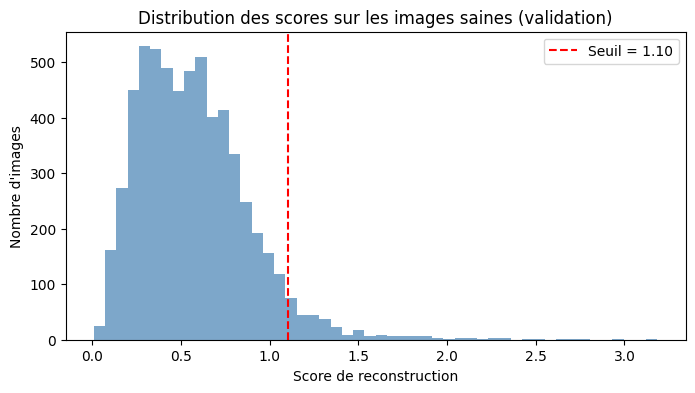

In [16]:
# Scores sur les images saines de validation
val_scores, _ = compute_anomaly_scores(model_ae, val_loader, DEVICE)

# Seuil = percentile 95 des scores sains
# donc 95% des images saines seront correctement classées comme saines
THRESHOLD = np.percentile(val_scores, 95)
print(f"Seuil (percentile 95 sur validation saines) : {THRESHOLD:.2f}")

# Visualisation de la distribution des scores sains
plt.figure(figsize=(8, 4))
plt.hist(val_scores, bins=50, color="steelblue", alpha=0.7)
plt.axvline(THRESHOLD, color="red", linestyle="--", label=f"Seuil = {THRESHOLD:.2f}")
plt.xlabel("Score de reconstruction")
plt.ylabel("Nombre d'images")
plt.title("Distribution des scores sur les images saines (validation)")
plt.legend()
plt.show()

### Evaluation du modèle

In [17]:
test_loader_full = DataLoader(
    test_dataset_t,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    generator=generator,
)

In [18]:
# Scores sur toutes les images de test
test_scores, test_labels = compute_anomaly_scores(model_ae, test_loader_full, DEVICE)

# Label binaire : 1 = pathologique, 0 = sain
binary_labels = (test_labels.sum(axis=1) > 0).astype(int)

# Prédictions avec le seuil
predictions = (test_scores > THRESHOLD).astype(int)

# Métriques
auc   = roc_auc_score(binary_labels, test_scores)
f1    = f1_score(binary_labels, predictions)
prec  = precision_score(binary_labels, predictions)
rec   = recall_score(binary_labels, predictions)

print(f"AUC-ROC   : {auc:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")

mlflow.log_metrics({
    "auc_roc": auc,
    "f1": f1,
    "precision": prec,
    "recall": rec,
    "threshold": THRESHOLD,
})

AUC-ROC   : 0.5294
F1-score  : 0.0948
Précision : 0.4902
Rappel    : 0.0525


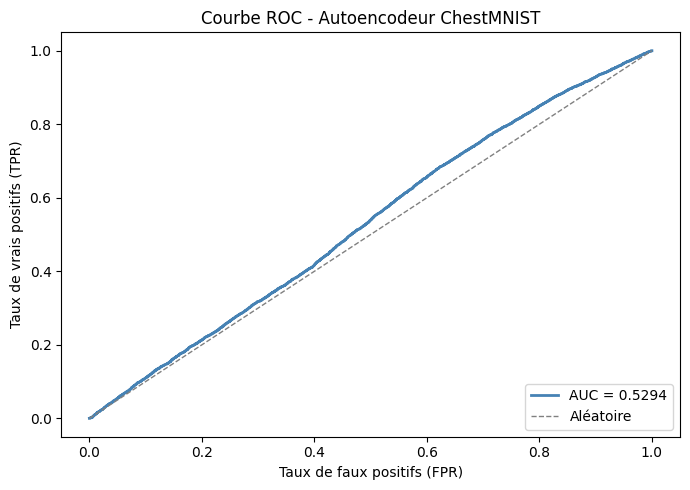

In [20]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(binary_labels, test_scores)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1, label="Aléatoire")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - Autoencodeur ChestMNIST")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Visualisation

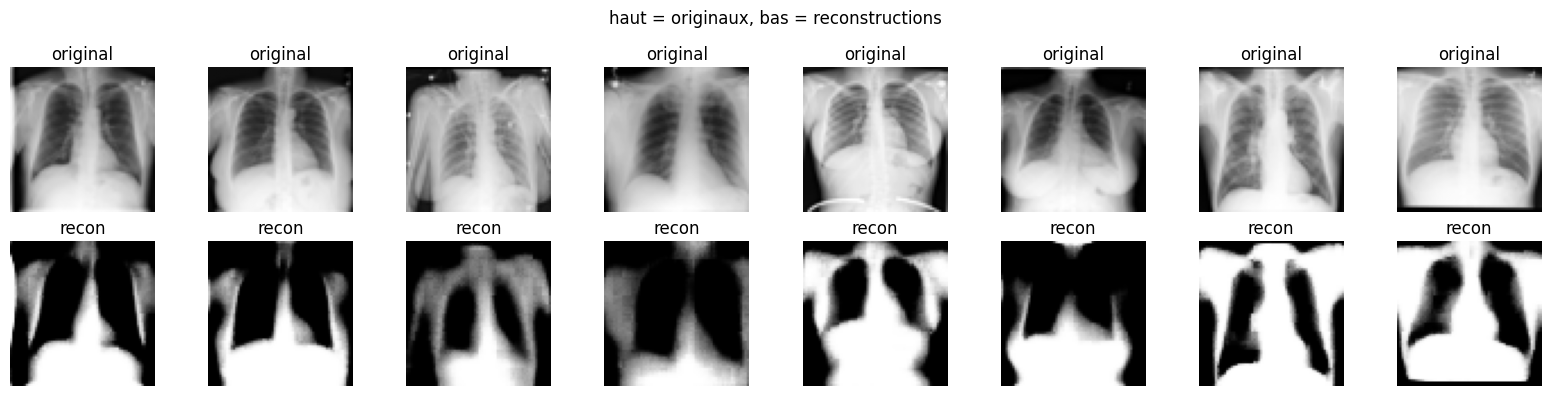

In [21]:
def plot_reconstructions(model, loader, device, n=8):
    model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        recon, _ = model(images)

    images = images.cpu()
    recon  = recon.cpu()

    fig, axes = plt.subplots(2, n, figsize=(2 * n, 4))
    for i in range(n):
        axes[0, i].imshow(images[i, 0], cmap="gray")
        axes[0, i].set_title("original")
        axes[0, i].axis("off")

        axes[1, i].imshow(recon[i, 0], cmap="gray")
        axes[1, i].set_title("recon")
        axes[1, i].axis("off")

    plt.suptitle("haut = originaux, bas = reconstructions")
    plt.tight_layout()
    plt.show()

plot_reconstructions(model_ae, test_loader, DEVICE)